In [1]:
pip install numpy pandas scipy scikit-learn torch matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [3]:
sensor1 = pd.read_csv('Downloads/data/g1_sensor1.csv', names=['time', 'normal', 'type1', 'type2', 'type3'])
sensor2 = pd.read_csv('Downloads/data/g1_sensor2.csv', names=['time', 'normal', 'type1', 'type2', 'type3'])
sensor3 = pd.read_csv('Downloads/data/g1_sensor3.csv', names=['time', 'normal', 'type1', 'type2', 'type3'])
sensor4 = pd.read_csv('Downloads/data/g1_sensor4.csv', names=['time', 'normal', 'type1', 'type2', 'type3'])

In [4]:
import os
print(os.getcwd())          # 현재 위치
print(os.listdir())         # 현재 폴더 파일 목록

C:\Users\user
['.anaconda', '.aws', '.azure', '.cagent', '.conda', '.config', '.continuum', '.docker', '.eclipse', '.ipynb_checkpoints', '.ipython', '.jupyter', '.kube', '.local', '.matplotlib', '.ms-ad', '.p2', '.ssh', '.VirtualBox', '.vscode', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'bentoml', 'Contacts', 'Cookies', 'Desktop', 'Documents', 'Downloads', 'eclipse-workspace', 'Favorites', 'Links', 'Local Settings', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'Pictures', 'PrintHood', 'Recent', 'save', 'Saved Games', 'Searches', 'SendTo', 'sre_project', 'Templates', 'Untitled-1.ipynb', 'Untitled.ipynb', 'Videos', '시작 메뉴']


In [5]:
sensor1

,time,normal,type1,type2,type3
0,0.000000,-0.853307,-3.464579,0.555219,3.919664
1,0.000736,-0.740463,-2.448986,-0.234687,4.145351
2,0.001472,-0.138630,-1.922383,-0.009000,2.941685
3,0.002208,0.049443,-0.906790,-0.272301,2.603155
4,0.002944,-0.289088,-0.568259,-0.986978,1.361874
...,...,...,...,...,...
190213,139.996768,-1.156354,-2.696750,0.844491,-2.109427
190214,139.997504,-0.930666,-1.380241,0.919720,-2.222270
190215,139.998240,-0.554521,-2.132532,0.731647,-2.109427
190216,139.998976,-1.419655,-2.433448,1.183022,-3.087405


In [6]:
# 4개의 센서로부터 140초간 수집한 데이터의 크기
# 열 값이 다른 이유는 각 센서의 샘플링 속도가 다르기 때문
print('sensor 1의 데이터 크기', sensor1.shape)
print('sensor 2의 데이터 크기', sensor2.shape)
print('sensor 3의 데이터 크기', sensor3.shape)
print('sensor 4의 데이터 크기', sensor4.shape)

sensor 1의 데이터 크기 (190218, 5)
sensor 2의 데이터 크기 (184211, 5)
sensor 3의 데이터 크기 (196079, 5)
sensor 4의 데이터 크기 (183969, 5)


In [7]:
# 전처리 1 - 계측 시간의 동일화를 위한 데이터 선형보간

from scipy import interpolate

x_new = np.arange(0, 140, 0.001)
y_new1 = []; y_new2 = []; y_new3 = []; y_new4 = []

for item in ['normal', 'type1', 'type2', 'type3']:
    f_linear1 = interpolate.interp1d(sensor1['time'], sensor1[item], kind='linear')
    y_new1.append(f_linear1(x_new))
    
    f_linear2 = interpolate.interp1d(sensor2['time'], sensor2[item], kind='linear')
    y_new2.append(f_linear2(x_new))
    
    f_linear3 = interpolate.interp1d(sensor3['time'], sensor3[item], kind='linear')
    y_new3.append(f_linear3(x_new))
    
    f_linear4 = interpolate.interp1d(sensor4['time'], sensor4[item], kind='linear')
    y_new4.append(f_linear4(x_new))

sensor1 = pd.DataFrame(np.array(y_new1).T, columns=['normal', 'type1', 'type2', 'type3'])
sensor2 = pd.DataFrame(np.array(y_new2).T, columns=['normal', 'type1', 'type2', 'type3'])
sensor3 = pd.DataFrame(np.array(y_new3).T, columns=['normal', 'type1', 'type2', 'type3'])
sensor4 = pd.DataFrame(np.array(y_new4).T, columns=['normal', 'type1', 'type2', 'type3'])

In [8]:
# 보간 결과 데이터 사이즈는 (140000, 4) 가 됨
sensor1

,normal,type1,type2,type3
0,-0.853307,-3.464579,0.555219,3.919664
1,-0.524588,-2.260096,-0.153734,3.713601
2,-0.003708,-1.193805,-0.197890,2.698827
3,-0.297674,-0.490986,-0.972668,1.338978
4,-0.091203,0.790771,-0.913384,0.701167
...,...,...,...,...
139995,-1.057411,-1.389236,0.664186,-1.498190
139996,-0.513635,-1.368793,1.050553,-0.982626
139997,-1.085213,-2.281763,0.868204,-2.144997
139998,-0.677177,-1.887220,0.792975,-2.146224


In [9]:
# 실제 취득된 형태로 데이터 재조정

normal_ = pd.concat([sensor1['normal'], sensor2['normal'], sensor3['normal'], sensor4['normal']], axis=1)
type1_  = pd.concat([sensor1['type1'],  sensor2['type1'],  sensor3['type1'],  sensor4['type1']],  axis=1)
type2_  = pd.concat([sensor1['type2'],  sensor2['type2'],  sensor3['type2'],  sensor4['type2']],  axis=1)
type3_  = pd.concat([sensor1['type3'],  sensor2['type3'],  sensor3['type3'],  sensor4['type3']],  axis=1)

normal_.columns = ['s1', 's2', 's3', 's4']
type1_.columns  = ['s1', 's2', 's3', 's4']
type2_.columns  = ['s1', 's2', 's3', 's4']
type3_.columns  = ['s1', 's2', 's3', 's4']

In [10]:
normal_

,s1,s2,s3,s4
0,-0.853307,0.048823,-0.437626,-1.116226
1,-0.524588,-0.029477,-0.149817,-0.659694
2,-0.003708,-0.004751,0.280889,-0.857345
3,-0.297674,0.009673,-0.303281,-0.685318
4,-0.091203,0.096215,-0.320263,-0.303108
...,...,...,...,...
139995,-1.057411,0.587429,0.275044,0.289837
139996,-0.513635,-0.137874,-0.045973,0.131462
139997,-1.085213,0.002242,-0.164593,-0.087380
139998,-0.677177,-0.308897,0.288252,1.319862


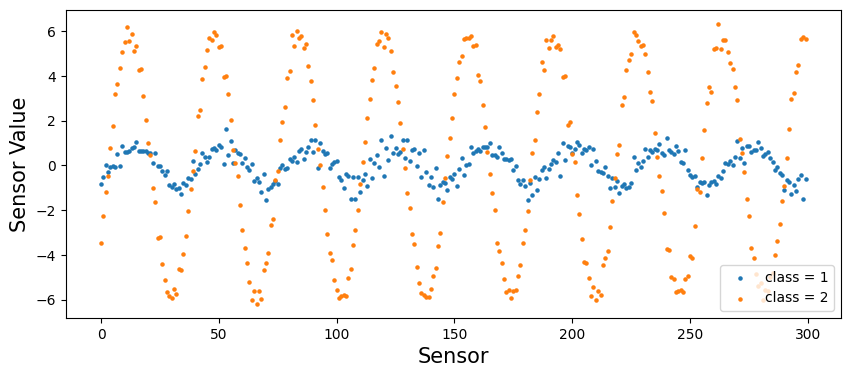

In [11]:
# 데이터 시각화 (시간에 따른 계측값)
# class 1 : 정상상태 / class 2 : 비정상 상태
plt.figure(figsize=(10, 4))
plt.scatter(range(0, 300), normal_['s1'][:300], label="class = " + str(1), marker='o', s=5)
plt.scatter(range(0, 300), type1_['s1'][:300],  label="class = " + str(2), marker='o', s=5)
plt.legend(loc="lower right")
plt.xlabel("Sensor", fontsize=15)
plt.ylabel("Sensor Value", fontsize=15)
plt.show()
plt.close()

In [12]:
# 데이터의 센서별 상관관계
normal_.corr()

,s1,s2,s3,s4
s1,1.000000,-0.007093,0.004297,-0.003377
s2,-0.007093,1.000000,-0.002992,0.111121
s3,0.004297,-0.002992,1.000000,-0.006434
s4,-0.003377,0.111121,-0.006434,1.000000


<AxesSubplot:>

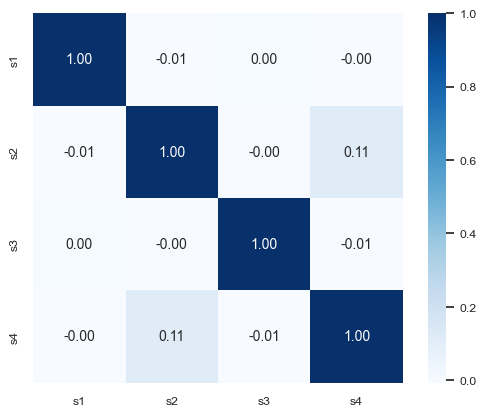

In [13]:
# 데이터 상관관계 시각화
names = ['s1','s2','s3','s4']
cm = np.corrcoef(normal_[names].values.T)
sns.set(font_scale=0.8)
sns.heatmap(cm, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, 
yticklabels=names, xticklabels=names, cmap=plt.cm.Blues)

In [14]:
# 전처리 2 - 데이터 필터링 (노이즈 제거)

M = 15

def moving_avg(series, M):
    result = np.convolve(series, np.ones(M), 'valid') / M
    return result.reshape(len(result), 1)

normal_s1 = moving_avg(normal_['s1'], M)
normal_s2 = moving_avg(normal_['s2'], M)
normal_s3 = moving_avg(normal_['s3'], M)
normal_s4 = moving_avg(normal_['s4'], M)

type1_s1 = moving_avg(type1_['s1'], M)
type1_s2 = moving_avg(type1_['s2'], M)
type1_s3 = moving_avg(type1_['s3'], M)
type1_s4 = moving_avg(type1_['s4'], M)

type2_s1 = moving_avg(type2_['s1'], M)
type2_s2 = moving_avg(type2_['s2'], M)
type2_s3 = moving_avg(type2_['s3'], M)
type2_s4 = moving_avg(type2_['s4'], M)

type3_s1 = moving_avg(type3_['s1'], M)
type3_s2 = moving_avg(type3_['s2'], M)
type3_s3 = moving_avg(type3_['s3'], M)
type3_s4 = moving_avg(type3_['s4'], M)

normal_temp = np.concatenate((normal_s1, normal_s2, normal_s3, normal_s4), axis=1)
type1_temp  = np.concatenate((type1_s1,  type1_s2,  type1_s3,  type1_s4),  axis=1)
type2_temp  = np.concatenate((type2_s1,  type2_s2,  type2_s3,  type2_s4),  axis=1)
type3_temp  = np.concatenate((type3_s1,  type3_s2,  type3_s3,  type3_s4),  axis=1)

In [15]:
# 전처리 3 - 데이터 정규화

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(normal_)

normal = scaler.transform(normal_temp)
type1  = scaler.transform(type1_temp)
type2  = scaler.transform(type2_temp)
type3  = scaler.transform(type3_temp)

C:\Users\user\anaconda3\envs\KAMP\lib\site-packages\sklearn\base.py:451: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  "X does not have valid feature names, but"
C:\Users\user\anaconda3\envs\KAMP\lib\site-packages\sklearn\base.py:451: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  "X does not have valid feature names, but"
C:\Users\user\anaconda3\envs\KAMP\lib\site-packages\sklearn\base.py:451: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  "X does not have valid feature names, but"
C:\Users\user\anaconda3\envs\KAMP\lib\site-packages\sklearn\base.py:451: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  "X does not have valid feature names, but"


In [16]:
# 데이터가 (0,1)로 정규화됨

print(normal)
print('------------------------------------------------')
print('normal data size = ', normal.shape)

[[0.57598822 0.50553898 0.56439491 0.44551164]
 [0.60960317 0.50513674 0.58169332 0.44848001]
 [0.62990663 0.5047345  0.59547186 0.46260474]
 ...
 [0.51874981 0.50106998 0.60999194 0.50715712]
 [0.49713039 0.51588928 0.6074125  0.53093987]
 [0.45708747 0.52025039 0.60349765 0.53976513]]
------------------------------------------------
normal data size =  (139986, 4)


In [17]:
# 숫자 확인의 효율성을 위해 데이터 사이즈 (100000, 4)로 조정

normal = normal[30000:130000][:]
type1  = type1[30000:130000][:]
type2  = type2[30000:130000][:]
type3  = type3[30000:130000][:]

print(normal)
print('------------------------------------------------')
print('normal data size = ', normal.shape)

[[0.42588581 0.56360116 0.59076635 0.45259554]
 [0.39980512 0.54859132 0.57699856 0.4486034 ]
 [0.38031149 0.54190146 0.57998374 0.44726771]
 ...
 [0.48028648 0.53048363 0.62114742 0.51024851]
 [0.44818273 0.53444251 0.62103995 0.49126006]
 [0.42832757 0.5501298  0.60917718 0.47827626]]
------------------------------------------------
normal data size =  (100000, 4)


In [18]:
# 데이터 분배 (학습/검증/테스트)
# 학습 : 검증 : 테스트 = 6 : 2 : 2
normal_train = normal[:60000];  normal_valid = normal[60000:80000];  normal_test = normal[80000:]
type1_train  = type1[:60000];   type1_valid  = type1[60000:80000];   type1_test  = type1[80000:]
type2_train  = type2[:60000];   type2_valid  = type2[60000:80000];   type2_test  = type2[80000:]
type3_train  = type3[:60000];   type3_valid  = type3[60000:80000];   type3_test  = type3[80000:]

train = np.concatenate((normal_train, type1_train, type2_train, type3_train))
valid = np.concatenate((normal_valid, type1_valid, type2_valid, type3_valid))
test  = np.concatenate((normal_test,  type1_test,  type2_test,  type3_test))

print("train data의 형태:", train.shape)
print("valid data의 형태:", valid.shape)
print(" test data의 형태:", test.shape)

train data의 형태: (240000, 4)
valid data의 형태: (80000, 4)
 test data의 형태: (80000, 4)


In [19]:
# 데이터 라벨링
# normal = 0 / type 1 = 1 / type 2 = 2 / type 3 = 3

train_label = np.concatenate((np.full((60000, 1), 0), np.full((60000, 1), 1), np.full((60000, 1), 2), np.full((60000, 1), 3)))
valid_label = np.concatenate((np.full((20000, 1), 0), np.full((20000, 1), 1), np.full((20000, 1), 2), np.full((20000, 1), 3)))
test_label  = np.concatenate((np.full((20000, 1), 0), np.full((20000, 1), 1), np.full((20000, 1), 2), np.full((20000, 1), 3)))

In [20]:
# 데이터 뒤섞기
# 순서에 의존하지 않고 임의의 데이터가 입력되는 것으로 간주하기 위함

idx = np.arange(train.shape[0])
np.random.shuffle(idx)
train       = train[idx]
train_label = train_label[idx]

idx_v = np.arange(valid.shape[0])
np.random.shuffle(idx_v)
valid       = valid[idx_v]
valid_label = valid_label[idx_v]

idx_t = np.arange(test.shape[0])
np.random.shuffle(idx_t)
test       = test[idx_t]
test_label = test_label[idx_t]

In [21]:
# 데이터 형태 변환 (array -> tensor 형태)

x_train = torch.from_numpy(train).float()
y_train = torch.from_numpy(train_label).float().T[0]

x_valid = torch.from_numpy(valid).float()
y_valid = torch.from_numpy(valid_label).float().T[0]

x_test = torch.from_numpy(test).float()
y_test = torch.from_numpy(test_label).float().T[0]

print("변경 전")
train

print("변경 후")
x_train

변경 전
변경 후


tensor([[0.6599, 0.5349, 0.5639, 0.4414],
        [0.3831, 0.2662, 0.5691, 0.5970],
        [0.6958, 0.5171, 0.5781, 0.5030],
        ...,
        [0.8897, 0.5963, 0.5751, 0.7591],
        [0.6093, 0.5395, 0.6125, 0.5559],
        [0.5484, 0.5358, 0.5908, 0.4371]])

In [22]:
# 데이터 묶기

from torch.utils.data import TensorDataset, DataLoader

train          = TensorDataset(x_train, y_train)
train_dataloader = DataLoader(train, batch_size=5000, shuffle=True)

valid          = TensorDataset(x_valid, y_valid)
valid_dataloader = DataLoader(valid, batch_size=len(x_valid), shuffle=False)

test           = TensorDataset(x_test, y_test)
test_dataloader  = DataLoader(test,  batch_size=len(x_valid), shuffle=False)

In [23]:
# 심층신경망(DNN)
# 모델 내 은닉층을 많이 늘려서 학습의 결과를 향상시키는 방법

class KAMP_DNN(nn.Module):
    def __init__(self):
        super(KAMP_DNN, self).__init__()
        self.layer1  = nn.Linear(in_features=4,   out_features=100)
        self.layer2  = nn.Linear(in_features=100, out_features=100)
        self.layer3  = nn.Linear(in_features=100, out_features=100)
        self.layer4  = nn.Linear(in_features=100, out_features=4)
        self.dropout = nn.Dropout(0.2)
        self.relu    = nn.ReLU()

    def forward(self, input):
        out = self.layer1(input)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.layer2(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.layer3(out)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.layer4(out)
        return out

model_check = KAMP_DNN()
print(model_check)

KAMP_DNN(
  (layer1): Linear(in_features=4, out_features=100, bias=True)
  (layer2): Linear(in_features=100, out_features=100, bias=True)
  (layer3): Linear(in_features=100, out_features=100, bias=True)
  (layer4): Linear(in_features=100, out_features=4, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
)


In [24]:
# 모델 학습

def train_model(model, criterion, optimizer, num_epochs, train_dataloader, PATH):
    loss_values   = []
    loss_values_v = []
    check         = 0
    accuracy_past = 0

    for epoch in range(1, num_epochs + 1):

        #---------------------- 모델 학습 ----------------------#
        model.train()
        batch_number = 0
        running_loss = 0.0

        for batch_idx, samples in enumerate(train_dataloader):
            x_train, y_train = samples
            optimizer.zero_grad()
            y_hat = model.forward(x_train)
            loss  = criterion(y_hat, y_train.long())
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            batch_number += 1

        loss_values.append(running_loss / batch_number)

        #---------------------- 모델 검증 ----------------------#
        model.eval()
        accuracy = 0.0
        total    = 0.0

        for batch_idx, data in enumerate(valid_dataloader):
            x_valid, y_valid = data
            v_hat  = model.forward(x_valid)
            v_loss = criterion(v_hat, y_valid.long())
            _, predicted = torch.max(v_hat.data, 1)
            total    += y_valid.size(0)
            accuracy += (predicted == y_valid).sum().item()

        loss_values_v.append(v_loss.item())
        accuracy = accuracy / total

        #---------------- Check for early stopping --------------#
        if epoch % 1 == 0:
            print('[Epoch {}/{}] [Train_Loss: {:.6f} / Valid_Loss: {:.6f}]'.format(
                epoch, num_epochs, loss.item(), v_loss.item()))
            print('[Epoch {}/{}] [Accuracy : {:.6f}]'.format(
                epoch, num_epochs, accuracy))

        if accuracy_past > accuracy:
            check += 1
        else:
            check = 0
        accuracy_past = accuracy

        if check > 50:
            print('This is time to do early stopping')
            break

    torch.save(model, PATH + 'model.pt')
    return loss_values, loss_values_v

In [25]:
import os
os.makedirs('save/DNN/', exist_ok=True)

In [26]:
# DNN 모델 학습

DNN_model  = KAMP_DNN()
num_epochs = 200
criterion  = nn.CrossEntropyLoss()
optimizer  = torch.optim.Adam(DNN_model.parameters())
PATH       = 'save/DNN/'

DNN_loss_values, DNN_loss_values_v = train_model(DNN_model, criterion, optimizer, num_epochs, train_dataloader, PATH)

[Epoch 1/200] [Train_Loss: 1.143788 / Valid_Loss: 1.088121]
[Epoch 1/200] [Accuracy : 0.437462]
[Epoch 2/200] [Train_Loss: 0.933101 / Valid_Loss: 0.874334]
[Epoch 2/200] [Accuracy : 0.489100]
[Epoch 3/200] [Train_Loss: 0.873313 / Valid_Loss: 0.848618]
[Epoch 3/200] [Accuracy : 0.503138]
[Epoch 4/200] [Train_Loss: 0.859363 / Valid_Loss: 0.838684]
[Epoch 4/200] [Accuracy : 0.496925]
[Epoch 5/200] [Train_Loss: 0.864665 / Valid_Loss: 0.829438]
[Epoch 5/200] [Accuracy : 0.515713]
[Epoch 6/200] [Train_Loss: 0.849747 / Valid_Loss: 0.820813]
[Epoch 6/200] [Accuracy : 0.550212]
[Epoch 7/200] [Train_Loss: 0.818399 / Valid_Loss: 0.803506]
[Epoch 7/200] [Accuracy : 0.580263]
[Epoch 8/200] [Train_Loss: 0.793604 / Valid_Loss: 0.772012]
[Epoch 8/200] [Accuracy : 0.607375]
[Epoch 9/200] [Train_Loss: 0.789128 / Valid_Loss: 0.751792]
[Epoch 9/200] [Accuracy : 0.625950]
[Epoch 10/200] [Train_Loss: 0.755184 / Valid_Loss: 0.730515]
[Epoch 10/200] [Accuracy : 0.631675]
[Epoch 11/200] [Train_Loss: 0.733162 /

[Epoch 85/200] [Train_Loss: 0.546301 / Valid_Loss: 0.597392]
[Epoch 85/200] [Accuracy : 0.731400]
[Epoch 86/200] [Train_Loss: 0.551254 / Valid_Loss: 0.588654]
[Epoch 86/200] [Accuracy : 0.739175]
[Epoch 87/200] [Train_Loss: 0.551569 / Valid_Loss: 0.603571]
[Epoch 87/200] [Accuracy : 0.731400]
[Epoch 88/200] [Train_Loss: 0.537977 / Valid_Loss: 0.592114]
[Epoch 88/200] [Accuracy : 0.735587]
[Epoch 89/200] [Train_Loss: 0.571129 / Valid_Loss: 0.589945]
[Epoch 89/200] [Accuracy : 0.737900]
[Epoch 90/200] [Train_Loss: 0.573152 / Valid_Loss: 0.593364]
[Epoch 90/200] [Accuracy : 0.738400]
[Epoch 91/200] [Train_Loss: 0.547854 / Valid_Loss: 0.589860]
[Epoch 91/200] [Accuracy : 0.736513]
[Epoch 92/200] [Train_Loss: 0.551103 / Valid_Loss: 0.594680]
[Epoch 92/200] [Accuracy : 0.734912]
[Epoch 93/200] [Train_Loss: 0.561888 / Valid_Loss: 0.592375]
[Epoch 93/200] [Accuracy : 0.736587]
[Epoch 94/200] [Train_Loss: 0.547607 / Valid_Loss: 0.590397]
[Epoch 94/200] [Accuracy : 0.736788]
[Epoch 95/200] [Trai

[Epoch 168/200] [Train_Loss: 0.542691 / Valid_Loss: 0.584813]
[Epoch 168/200] [Accuracy : 0.740237]
[Epoch 169/200] [Train_Loss: 0.541147 / Valid_Loss: 0.591654]
[Epoch 169/200] [Accuracy : 0.733888]
[Epoch 170/200] [Train_Loss: 0.550714 / Valid_Loss: 0.583856]
[Epoch 170/200] [Accuracy : 0.741850]
[Epoch 171/200] [Train_Loss: 0.545145 / Valid_Loss: 0.590736]
[Epoch 171/200] [Accuracy : 0.738637]
[Epoch 172/200] [Train_Loss: 0.541568 / Valid_Loss: 0.594724]
[Epoch 172/200] [Accuracy : 0.735313]
[Epoch 173/200] [Train_Loss: 0.532976 / Valid_Loss: 0.590540]
[Epoch 173/200] [Accuracy : 0.739850]
[Epoch 174/200] [Train_Loss: 0.548030 / Valid_Loss: 0.589492]
[Epoch 174/200] [Accuracy : 0.739400]
[Epoch 175/200] [Train_Loss: 0.545264 / Valid_Loss: 0.586237]
[Epoch 175/200] [Accuracy : 0.742800]
[Epoch 176/200] [Train_Loss: 0.548979 / Valid_Loss: 0.594361]
[Epoch 176/200] [Accuracy : 0.731213]
[Epoch 177/200] [Train_Loss: 0.552538 / Valid_Loss: 0.587561]
[Epoch 177/200] [Accuracy : 0.738487]


In [27]:
# 모델 평가

def test_model(model, PATH):
    model = torch.load(PATH + 'model.pt')

    #---------------------- 모델 시험 ----------------------#
    model.eval()
    total    = 0.0
    accuracy = 0.0

    for batch_idx, data in enumerate(test_dataloader):
        x_test, y_test = data
        t_hat  = model(x_test)
        _, predicted = torch.max(t_hat.data, 1)
        total    += y_test.size(0)
        accuracy += (predicted == y_test).sum().item()

    accuracy = accuracy / total
    #-------------------------------------------------------#
    print(accuracy)

In [28]:
# 혼동 행렬

from sklearn.metrics import classification_report, confusion_matrix

def draw_confusion_matrix(model, xt, yt, PATH):
    y_pred = []
    y_true = []

    model.eval()
    y_hat  = model(xt)
    output = (torch.max(torch.exp(y_hat), 1)[1]).data.cpu().numpy()
    y_pred.extend(output)
    labels = yt.data.cpu().numpy()
    y_true.extend(labels)

    # 분류 항목
    classes = ('Normal', 'Type1', 'Type2','Type3')

    # Confusion Matrix 생성
    plt.figure(figsize=(7, 5))
    dlen  = float(len(xt))
    cm    = confusion_matrix(y_true, y_pred)
    df_cm = pd.DataFrame(cm / dlen,
                         index  =[i for i in classes],
                         columns=[i for i in classes])

    sns.heatmap(df_cm, annot=True, cmap=plt.cm.Blues)
    plt.title("Confusion Matrix", size=24, fontweight='bold')
    plt.xlabel("Predicted Label", size=16)
    plt.ylabel("Actual Label",   size=16)
    plt.rc('xtick', labelsize=12)
    plt.rc('ytick', labelsize=12)
    plt.yticks(rotation=0)
    plt.savefig(PATH + 'cm_output.png')

In [29]:
# 손실 그래프

def plot_loss_graph(loss_values, loss_values_v, PATH):
    plt.figure()
    plt.plot(loss_values)
    plt.plot(loss_values_v)
    plt.title("Training & Validation Loss")
    plt.ylabel("loss",  fontsize="large")
    plt.xlabel("epoch", fontsize="large")
    plt.legend(["train", "validation"])
    plt.tight_layout()
    plt.savefig(PATH + 'lossplot_output.png')

0.7629


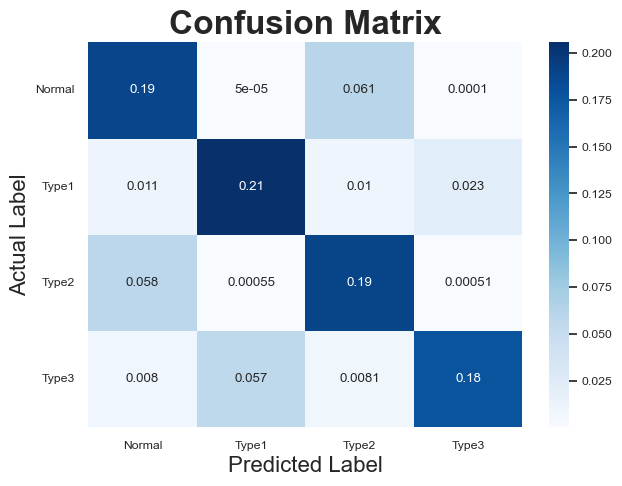

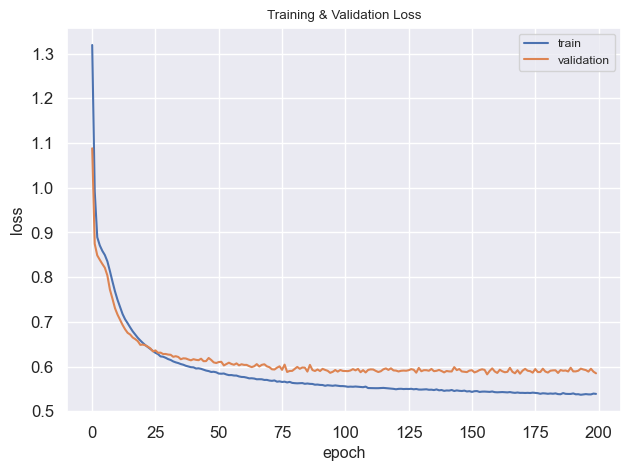

In [30]:
PATH ='save/DNN/'
test_model(DNN_model, PATH)
draw_confusion_matrix(DNN_model, x_test, y_test, PATH)
plot_loss_graph(DNN_loss_values, DNN_loss_values_v, PATH)

In [ ]:
model = torch.load('save/DNN/model.pt')
model.eval()